# Risk Predictor Training Demo
This notebook is aligned with runtime deployment: e2e sequence model, 16-frame window, 12-frame burn-in, and 4-frame prediction.
It keeps DataLoader throughput settings (`num_workers`, `prefetch_factor`, `persistent_workers`) for stable multi-epoch training.

## Step 1 - Optional Climate Model Training
Run the next cell if you want to train or resume the environment multitask model (day/night + climate).
Set `run_climate_training = False` to skip it.

In [ ]:
from MIREIA.perception.climate_model_train import train_environment_model

run_climate_training = False

climate_result = None
if run_climate_training:
    climate_result = train_environment_model(
        epochs=1,
        batch_size=256,
        lr=1e-4,
        weight_decay=1e-4,
        num_workers=16,
        prefetch_factor=1,
        disable_amp=False,
        log_every=25,
        grad_accum_steps=1,
        grad_clip=None,
        image_size=512,
        dropout=0.2,
        day_loss_weight=1.0,
        weather_loss_weight=1.0,
        scenarios_root=None,
        subset_ratio=None,
        subset_seed=42,
        subset_mode="first",
        max_scenarios=None,
        frame_subset_ratio=None,
        frame_subset_seed=42,
        frame_subset_mode="random",
        checkpoint_path="",
        checkpoint_name="environment_multitask_checkpoint.pt",
        no_resume=False,
        device="",
        resize_images=False,
    )

    print("Saved:", climate_result["checkpoint_path"])
    print("Classes:", climate_result["idx_to_climate"])
    print("Final epoch:", climate_result["final_epoch"])
else:
    print("Climate training skipped (set run_climate_training=True to enable).")

## Step 2 - E2E Temporal Configuration
The next cell only defines sequence settings used by e2e risk training.
Check that `burn_in_frames + m_eval_frames == seq_len`.

In [ ]:
import torch
torch.backends.cudnn.benchmark = True

from MIREIA.config import Config

# Runtime-aligned training setup (matches streaming inference path).
model_type = "e2e"  # use e2e sequence mode for FIFO temporal deployment
m_eval_frames = Config.INFERENCE_EVAL_FRAMES  # expected: 4
seq_len = Config.INFERENCE_SEQUENCE_LENGTH  # expected: 16
burn_in_frames = Config.INFERENCE_BURN_IN_FRAMES  # expected: 12
if burn_in_frames + m_eval_frames != seq_len:
    raise ValueError(
        f"Invalid temporal setup: burn_in({burn_in_frames}) + eval({m_eval_frames}) != seq_len({seq_len})"
    )

## Step 3 - E2E Risk Training / Resume
Run the next cell to train or resume the e2e risk model and save `e2e_result`.
`e2e_result` contains model, loaders, history, and checkpoint info used by later cells.

In [ ]:
import torch
from MIREIA.config import Config
from MIREIA.perception.e2e_model_train import train_e2e_model

run_e2e_training = False

e2e_result = None
if run_e2e_training:
    e2e_result = train_e2e_model(
        resume_epochs=1,
        model_type="e2e",
        seq_len=Config.INFERENCE_SEQUENCE_LENGTH,
        burn_in_frames=Config.INFERENCE_BURN_IN_FRAMES,
        m_eval_frames=Config.INFERENCE_EVAL_FRAMES,
        batch_size=8,
        num_workers=8,
        prefetch_factor=4,
        pin_memory=True,
        persistent_workers=True,
        learning_rate=1e-4,
        use_amp=True,
        window_subset_ratio=None,
        window_subset_mode="random",
        window_subset_seed=Config.RANDOM_SEED,
        checkpoint_path="",
        checkpoint_name="e2e_risk_checkpoint.pt",
        device="cuda",
        grad_clip=None,
        grad_accum_steps=1,
    )

    # Compatibility aliases used by downstream visualization cells.
    model = e2e_result["model"]
    train_loader = e2e_result["train_loader"]
    val_loader = e2e_result["val_loader"]
    history = e2e_result["history"]
    checkpoint_path = e2e_result["checkpoint_path"]
    model_type = e2e_result.get("model_type_internal", e2e_result["model_type"])
    m_eval_frames = e2e_result["m_eval_frames"]
    seq_len = e2e_result["seq_len"]
    burn_in_frames = e2e_result["burn_in_frames"]
    target_mode = e2e_result["target_mode"]
    device = torch.device(e2e_result["device"])

    print("Saved:", e2e_result["checkpoint_path"])
    print("Final epoch:", e2e_result["final_epoch"])
else:
    print("E2E training skipped (set run_e2e_training=True to enable).")

## Step 4 - Metrics Summary (Can Load History Without Training)
The next cell prints run metrics and supports checkpoint-only history loading.
If no in-memory result exists, keep `load_saved_history_only = True` to inspect saved history.

In [ ]:
import os
import torch

from MIREIA.config import Config

def _default_history_checkpoint(run_name: str) -> str:
    if run_name == "climate":
        return os.path.join(Config.PATH_TO_MODELS, "environment_multitask_checkpoint.pt")
    return os.path.join(Config.PATH_TO_MODELS, "e2e_risk_checkpoint.pt")

def _load_history_only_result(run_name: str, checkpoint_path: str = "") -> dict | None:
    path = checkpoint_path or _default_history_checkpoint(run_name)
    if not os.path.isfile(path):
        print(f"Checkpoint not found: {path}")
        return None

    payload = torch.load(path, map_location="cpu")
    if not isinstance(payload, dict):
        print(f"Unsupported checkpoint payload type: {type(payload)}")
        return None

    history = payload.get("history", {})
    if not isinstance(history, dict):
        history = {}

    loaded_epoch = int(payload.get("epoch", 0))
    seq_len_loaded = int(payload.get("seq_len", Config.INFERENCE_SEQUENCE_LENGTH))
    m_eval_loaded = int(payload.get("m_eval_frames", Config.INFERENCE_EVAL_FRAMES))
    raw_type = str(payload.get("model_type_internal", payload.get("model_type", "e2e"))).lower()
    model_type_internal = "single" if raw_type == "single" else "e2e"

    return {
        "history": history,
        "checkpoint_path": path,
        "model_type": "environment_multitask" if run_name == "climate" else "e2e",
        "model_type_internal": "environment_multitask" if run_name == "climate" else model_type_internal,
        "m_eval_frames": m_eval_loaded,
        "seq_len": seq_len_loaded,
        "burn_in_frames": max(0, seq_len_loaded - m_eval_loaded),
        "target_mode": payload.get("target_mode", "sequence"),
        "idx_to_climate": payload.get("idx_to_climate", []),
        "climate_to_idx": payload.get("climate_to_idx", {}),
        "device": "cpu",
        "start_epoch": loaded_epoch + 1,
        "final_epoch": loaded_epoch,
    }

# Summary metrics (supports both e2e and climate runs)
visualize_run = "e2e"  # "e2e" or "climate"
load_saved_history_only = True  # True lets you inspect metrics without training now
history_checkpoint_path = ""  # Optional explicit checkpoint path

if visualize_run == "climate":
    active_result = climate_result if "climate_result" in globals() else None
elif visualize_run == "e2e":
    active_result = e2e_result if "e2e_result" in globals() else None
else:
    raise ValueError("visualize_run must be 'e2e' or 'climate'")

if active_result is None and load_saved_history_only:
    active_result = _load_history_only_result(visualize_run, history_checkpoint_path)
    if active_result is not None:
        print(f"Loaded history-only result from: {active_result['checkpoint_path']}")

if active_result is None:
    print(f"No result found for {visualize_run}. Run training or enable history loading.")
else:
    active_train_loader = active_result.get("train_loader")
    active_val_loader = active_result.get("val_loader")
    active_history = active_result.get("history", {})

    train_samples = len(active_train_loader.dataset) if active_train_loader is not None else 0
    val_samples = len(active_val_loader.dataset) if active_val_loader is not None else 0
    train_batches = len(active_train_loader) if active_train_loader is not None else 0
    val_batches = len(active_val_loader) if active_val_loader is not None else 0

    print(f"Run: {visualize_run}")
    print(f"Checkpoint: {active_result.get('checkpoint_path', '(in-memory only)')}")
    print(f"Train samples: {train_samples}")
    print(f"Val samples:   {val_samples}")
    print(f"Train batches: {train_batches}")
    print(f"Val batches:   {val_batches}")

    if active_history.get("train_loss"):
        print(f"Best train loss: {min(active_history['train_loss']):.6f}")
    if active_history.get("val_loss"):
        print(f"Best val loss:   {min(active_history['val_loss']):.6f}")
    if active_history.get("train_day_acc"):
        print(f"Best train day acc:     {max(active_history['train_day_acc']):.4f}")
    if active_history.get("train_weather_acc"):
        print(f"Best train climate acc: {max(active_history['train_weather_acc']):.4f}")
    if active_history.get("val_day_acc"):
        print(f"Best val day acc:       {max(active_history['val_day_acc']):.4f}")
    if active_history.get("val_weather_acc"):
        print(f"Best val climate acc:   {max(active_history['val_weather_acc']):.4f}")

if torch.cuda.is_available():
    mem_alloc = torch.cuda.max_memory_allocated() / (1024 ** 3)
    mem_reserved = torch.cuda.max_memory_reserved() / (1024 ** 3)
    print(f"Peak CUDA allocated: {mem_alloc:.2f} GB")
    print(f"Peak CUDA reserved:  {mem_reserved:.2f} GB")

## Step 5 - Training Curves
The next cell plots losses (and climate accuracies when applicable).
It can also run from checkpoint history if `load_saved_history_only = True`.

In [ ]:
import os
import matplotlib.pyplot as plt
import torch

from MIREIA.config import Config

if "_load_history_only_result" not in globals():
    def _default_history_checkpoint(run_name: str) -> str:
        if run_name == "climate":
            return os.path.join(Config.PATH_TO_MODELS, "environment_multitask_checkpoint.pt")
        return os.path.join(Config.PATH_TO_MODELS, "e2e_risk_checkpoint.pt")

    def _load_history_only_result(run_name: str, checkpoint_path: str = "") -> dict | None:
        path = checkpoint_path or _default_history_checkpoint(run_name)
        if not os.path.isfile(path):
            print(f"Checkpoint not found: {path}")
            return None
        payload = torch.load(path, map_location="cpu")
        if not isinstance(payload, dict):
            print(f"Unsupported checkpoint payload type: {type(payload)}")
            return None
        history = payload.get("history", {})
        if not isinstance(history, dict):
            history = {}
        raw_type = str(payload.get("model_type_internal", payload.get("model_type", "e2e"))).lower()
        model_type_internal = "single" if raw_type == "single" else "e2e"
        return {
            "history": history,
            "checkpoint_path": path,
            "model_type": "environment_multitask" if run_name == "climate" else "e2e",
            "model_type_internal": "environment_multitask" if run_name == "climate" else model_type_internal,
        }

# Loss plot for either e2e or climate run
visualize_run = "e2e"  # "e2e" or "climate"
load_saved_history_only = True
history_checkpoint_path = ""

if visualize_run == "climate":
    active_result = climate_result if "climate_result" in globals() else None
elif visualize_run == "e2e":
    active_result = e2e_result if "e2e_result" in globals() else None
else:
    raise ValueError("visualize_run must be 'e2e' or 'climate'")

if active_result is None and load_saved_history_only:
    active_result = _load_history_only_result(visualize_run, history_checkpoint_path)
    if active_result is not None:
        print(f"Loaded history-only result from: {active_result['checkpoint_path']}")

if active_result is None:
    print(f"No result found for {visualize_run}. Run training or enable history loading.")
else:
    active_history = active_result.get("history", {})

    if active_history.get("train_loss"):
        plt.figure(figsize=(7, 4))
        plt.plot(active_history["train_loss"], label="train_loss")
        if active_history.get("val_loss"):
            plt.plot(active_history["val_loss"], label="val_loss")

        if visualize_run == "climate":
            if active_history.get("train_day_acc"):
                plt.plot(active_history["train_day_acc"], label="train_day_acc")
            if active_history.get("val_day_acc"):
                plt.plot(active_history["val_day_acc"], label="val_day_acc")
            if active_history.get("train_weather_acc"):
                plt.plot(active_history["train_weather_acc"], label="train_climate_acc")
            if active_history.get("val_weather_acc"):
                plt.plot(active_history["val_weather_acc"], label="val_climate_acc")

        plt.xlabel("Epoch")
        plt.ylabel("Metric")
        plt.title(f"Training Curves ({visualize_run})")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("No training history found in the selected run/checkpoint.")

## Step 6 - Optional Road Segmentation Training (Dual-Head Multitask)
Run the next cell to train one compact model that predicts both lane lines and drivable road masks.
Set `run_road_seg_training = False` to skip training and use checkpoint loading in later cells.

In [ ]:
import importlib
import torch

from MIREIA.config import Config
import MIREIA.perception.road_segmentation as road_seg_model_module
import MIREIA.perception.road_segmentation_train as road_seg_train_module

# Reload model first, then trainer, so trainer binds the latest model class.
road_seg_model_module = importlib.reload(road_seg_model_module)
road_seg_train_module = importlib.reload(road_seg_train_module)
train_road_segmentation_model = road_seg_train_module.train_road_segmentation_model

run_road_seg_training = True

road_seg_result = None
if run_road_seg_training:
    road_seg_result = train_road_segmentation_model(
        dataset_name="bnsapa/road-detection",
        epochs=50,
        batch_size=1,
        lr=1e-4,
        weight_decay=1e-4,
        image_size=256,
        dropout=0.1,
        backbone_pretrained=True,
        num_workers=8,  # safer default on Windows shared-memory limits
        pin_memory=torch.cuda.is_available(),
        prefetch_factor=4,
        persistent_workers=False,
        subset_ratio=None,
        val_subset_ratio=None,
        subset_seed=Config.RANDOM_SEED,
        subset_mode="random",
        disable_amp=False,
        pred_threshold=0.5,
        lane_loss_weight=1.0,
        road_loss_weight=1.0,
        grad_accum_steps=1,
        grad_clip=None,
        checkpoint_path="",
        checkpoint_name="road_segmentation_multitask_checkpoint.pt",
        best_checkpoint_path="",
        best_checkpoint_name="road_segmentation_multitask_best.pt",
        no_resume=False,
        device="",
        log_every=25,
    )

    print("Road segmentation checkpoint:", road_seg_result["checkpoint_path"])
    print("Best checkpoint:", road_seg_result["best_checkpoint_path"])
    print("Best mean IoU:", f"{road_seg_result['best_mean_iou']:.4f}")
    print("Final epoch:", road_seg_result["final_epoch"])
else:
    print("Road segmentation training skipped (set run_road_seg_training=True to enable).")

## Step 7 - Segmentation Metrics Summary (Lane + Road)
The next cell reports multitask training and validation metrics for both heads.
If no in-memory result exists, it can load metadata and history from a saved checkpoint.

In [ ]:
import importlib
import os

from MIREIA.config import Config
import MIREIA.perception.road_segmentation as road_seg_model_module
import MIREIA.perception.road_segmentation_train as road_seg_train_module

# Reload model first, then trainer, so loader paths bind the latest model class.
road_seg_model_module = importlib.reload(road_seg_model_module)
road_seg_train_module = importlib.reload(road_seg_train_module)
load_road_segmentation_model = road_seg_train_module.load_road_segmentation_model

seg_checkpoint_name = "road_segmentation_multitask_checkpoint.pt"
seg_checkpoint_path = os.path.join(Config.PATH_TO_MODELS, seg_checkpoint_name)
load_saved_seg_result = True

active_seg_result = road_seg_result if "road_seg_result" in globals() else None
if active_seg_result is None and load_saved_seg_result:
    if os.path.isfile(seg_checkpoint_path):
        active_seg_result = load_road_segmentation_model(checkpoint_path=seg_checkpoint_path)
        print(f"Loaded segmentation result from: {active_seg_result['checkpoint_path']}")
    else:
        print(f"Checkpoint not found: {seg_checkpoint_path}")

if active_seg_result is None:
    print("No road segmentation result found. Run training or provide a valid checkpoint.")
else:
    seg_history = active_seg_result.get("history", {})
    print("Run: road_segmentation_multitask")
    print("Tasks:", active_seg_result.get("tasks", ["lane", "road"]))
    print("Dataset:", active_seg_result.get("dataset_name", "bnsapa/road-detection"))
    print("Checkpoint:", active_seg_result.get("checkpoint_path", "(in-memory only)"))
    print("Image size:", active_seg_result.get("image_size", (256, 256)))
    print("Threshold:", active_seg_result.get("pred_threshold", 0.5))
    print("Best mean IoU:", f"{float(active_seg_result.get('best_mean_iou', 0.0)):.4f}")
    print("Final epoch:", int(active_seg_result.get("final_epoch", 0)))

    if seg_history.get("train_loss"):
        print("Best train loss:", f"{min(seg_history['train_loss']):.6f}")
    if seg_history.get("val_loss"):
        print("Best val loss:", f"{min(seg_history['val_loss']):.6f}")

    if seg_history.get("train_lane_iou"):
        print("Best train lane IoU:", f"{max(seg_history['train_lane_iou']):.4f}")
    if seg_history.get("val_lane_iou"):
        print("Best val lane IoU:", f"{max(seg_history['val_lane_iou']):.4f}")
    if seg_history.get("train_road_iou"):
        print("Best train road IoU:", f"{max(seg_history['train_road_iou']):.4f}")
    if seg_history.get("val_road_iou"):
        print("Best val road IoU:", f"{max(seg_history['val_road_iou']):.4f}")
    if seg_history.get("train_mean_iou"):
        print("Best train mean IoU:", f"{max(seg_history['train_mean_iou']):.4f}")
    if seg_history.get("val_mean_iou"):
        print("Best val mean IoU:", f"{max(seg_history['val_mean_iou']):.4f}")

    if seg_history.get("train_lane_dice"):
        print("Best train lane Dice:", f"{max(seg_history['train_lane_dice']):.4f}")
    if seg_history.get("val_lane_dice"):
        print("Best val lane Dice:", f"{max(seg_history['val_lane_dice']):.4f}")
    if seg_history.get("train_road_dice"):
        print("Best train road Dice:", f"{max(seg_history['train_road_dice']):.4f}")
    if seg_history.get("val_road_dice"):
        print("Best val road Dice:", f"{max(seg_history['val_road_dice']):.4f}")
    if seg_history.get("train_mean_dice"):
        print("Best train mean Dice:", f"{max(seg_history['train_mean_dice']):.4f}")
    if seg_history.get("val_mean_dice"):
        print("Best val mean Dice:", f"{max(seg_history['val_mean_dice']):.4f}")

## Step 8 - Optional Speed Fusion Training
Trains the fused two-frame speed regressor using scenario JSONL labels (`true_ego_speed` by default).
Set `run_speed_fusion_training = True` to launch training/resume and save `speed_fusion_result`.

In [ ]:
import os

import matplotlib.pyplot as plt
import torch

from MIREIA.config import Config
from MIREIA.perception import train_speed_fusion_model

run_speed_fusion_training = True
device_name = "cuda" if torch.cuda.is_available() else "cpu"

speed_fusion_result = None
if run_speed_fusion_training:
    speed_fusion_result = train_speed_fusion_model(
        resume_epochs=1,
        batch_size=4,
        learning_rate=3e-4,
        scenarios_root=Config.PATH_TO_SCENARIOS,
        speed_key="true_ego_speed",
        checkpoint_name="speed_fusion_checkpoint.pt",
        checkpoint_path="",
        model_device=device_name,
        feature_device=device_name,
        cache_dir=os.path.join(Config.PATH_TO_MODELS, "speed_fusion_cache"),
        max_ram_cache_entries=256,
        num_workers=0,
        pin_memory=False,
        max_scenarios=None,
        subset_ratio=0.005,
        pair_stride=1,
        pair_subset_ratio=None,
        log_every=10,
        grad_clip=None,
        use_cache=True,
    )

    print("Saved:", speed_fusion_result["checkpoint_path"])

    history = speed_fusion_result.get("history", {})
    if history.get("train_loss"):
        plt.figure(figsize=(7, 4))
        plt.plot(history["train_loss"], label="train_loss")
        if history.get("val_loss"):
            plt.plot(history["val_loss"], label="val_loss")
        if history.get("train_rmse"):
            plt.plot(history["train_rmse"], label="train_rmse")
        if history.get("val_rmse"):
            plt.plot(history["val_rmse"], label="val_rmse")
        plt.xlabel("Epoch")
        plt.ylabel("Metric")
        plt.title("Speed Fusion Training")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("Speed fusion training skipped (set run_speed_fusion_training=True to enable).")

In [1]:
from pathlib import Path

import torch
from ultralytics import YOLO

from MIREIA.config import Config
from MIREIA.perception import (
    DepthAnythingV2Estimator,
    FeatureIntegrator,
    create_environment_classifier_predictor,
    load_road_segmentation_model,
)

# Optional: set these to any two frames you want to fuse.
FUSION_FRAME1_PATH = Path(Config.PATH_TO_SCENARIOS) / "03A_WetNoon_Town05_HighVol" / "dataset" / "images" / "rgb_000190.png"
FUSION_FRAME2_PATH = Path(Config.PATH_TO_SCENARIOS) / "03A_WetNoon_Town05_HighVol" / "dataset" / "images" / "rgb_000195.png"

MODEL_PATHS = {
    "yolo": Path(Config.PATH_TO_MODELS) / "yolo11s.pt",
    "depth": Path(Config.PATH_TO_MODELS) / "depth_anything_v2_vits.pth",
    "climate": Path(Config.PATH_TO_MODELS) / "environment_multitask_checkpoint.pt",
    "road_seg": Path(Config.PATH_TO_MODELS) / "road_segmentation_multitask_checkpoint.pt",
}

missing_frames = [p for p in (FUSION_FRAME1_PATH, FUSION_FRAME2_PATH) if not p.is_file()]
if missing_frames:
    print("Fusion demo skipped. Missing frame(s):")
    for p in missing_frames:
        print(f" - {p}")
else:
    required_models = ["yolo", "depth"]
    missing_required = [name for name in required_models if not MODEL_PATHS[name].is_file()]

    if missing_required:
        print("Fusion demo skipped. Missing required checkpoint(s):")
        for name in missing_required:
            print(f" - {name}: {MODEL_PATHS[name]}")
    else:
        device_name = "cuda" if torch.cuda.is_available() else "cpu"

        yolo_model = YOLO(str(MODEL_PATHS["yolo"]))
        depth_estimator = DepthAnythingV2Estimator(
            checkpoint_path=MODEL_PATHS["depth"],
            encoder="vits",
            device=device_name,
        )

        environment_predictor = None
        if MODEL_PATHS["climate"].is_file():
            environment_predictor = create_environment_classifier_predictor(
                checkpoint_path=str(MODEL_PATHS["climate"]),
                device=device_name,
            )
        else:
            print(f"[info] Climate checkpoint not found, using environment defaults: {MODEL_PATHS['climate']}")

        road_segmentation = None
        if MODEL_PATHS["road_seg"].is_file():
            road_segmentation = load_road_segmentation_model(
                checkpoint_path=str(MODEL_PATHS["road_seg"]),
                device=device_name,
            )
        else:
            print(f"[info] Road segmentation checkpoint not found, using road default=0.0: {MODEL_PATHS['road_seg']}")

        feature_integrator = FeatureIntegrator()
        fused_state = feature_integrator.extract_state_vector_from_sources(
            source_frame1=FUSION_FRAME1_PATH,
            source_frame2=FUSION_FRAME2_PATH,
            yolo_model=yolo_model,
            depth_estimator=depth_estimator,
            environment_predictor=environment_predictor,
            road_segmentation=road_segmentation,
        )

        print(f"Fused state shape: {tuple(fused_state.shape)}")
        print(f"Fused state dtype: {fused_state.dtype}")
        print(f"Fused state length: {fused_state.numel()}")
        for i in range(min(32, fused_state.numel())):
            print(f"  [{i}] {fused_state.view(-1)[i].item():.6f}")

xFormers not available
xFormers not available


Fused state shape: (32,)
Fused state dtype: torch.float32
Fused state length: 32
  [0] 2.000000
  [1] 0.081339
  [2] 0.052875
  [3] 0.199544
  [4] 0.318889
  [5] 0.999140
  [6] 0.990811
  [7] 0.965222
  [8] 0.955465
  [9] -0.314973
  [10] -0.115489
  [11] 0.000000
  [12] 0.000000
  [13] 8.148971
  [14] 8.148971
  [15] 3.753815
  [16] 3.753815
  [17] 0.411942
  [18] 1.000000
  [19] 0.000000
  [20] 0.000001
  [21] 0.000000
  [22] 0.000000
  [23] 0.000000
  [24] 0.000000
  [25] 0.000001
  [26] 0.000002
  [27] 0.000000
  [28] 0.999986
  [29] 0.000009
  [30] 0.000000
  [31] 0.000000


## Step 9 - Dataset Labeling: Startup BBox + Full Feature Vectors
Generates or reuses `dataset_labeled.jsonl`, previews startup bounding boxes, and writes a 32D fused feature vector per image using all perception models.

Selecting scenarios by index range [1:5) out of 64 total:
 - [1] 01B_ClearNoon_Town01_LowVol -> t:\TFG\MIREIA\scenarios\01B_ClearNoon_Town01_LowVol
 - [2] 01C_ClearNoon_Town02_HighVol -> t:\TFG\MIREIA\scenarios\01C_ClearNoon_Town02_HighVol
 - [3] 01D_ClearNoon_Town02_LowVol -> t:\TFG\MIREIA\scenarios\01D_ClearNoon_Town02_LowVol
 - [4] 02A_CloudyNoon_Town03_HighVol -> t:\TFG\MIREIA\scenarios\02A_CloudyNoon_Town03_HighVol

Scenario -> letter -> bbox mapping:
 - 01B_ClearNoon_Town01_LowVol (B): (0, 320, 512, 512)
 - 01C_ClearNoon_Town02_HighVol (C): (0, 300, 512, 512)
 - 01D_ClearNoon_Town02_LowVol (D): (0, 440, 512, 512)
 - 02A_CloudyNoon_Town03_HighVol (A): (0, 305, 512, 512)


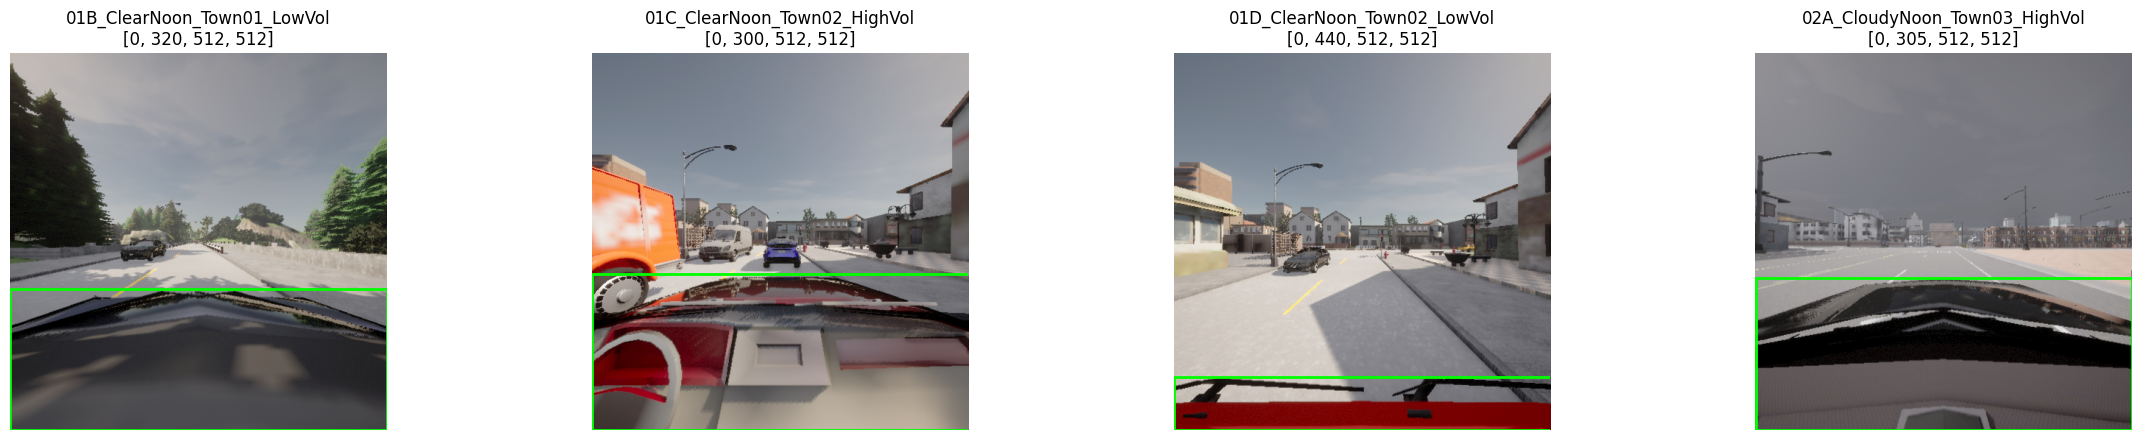

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

from MIREIA.config import Config
from MIREIA.data_collection.dataset_utils import load_jsonl_records, resolve_image_path

# Define dashboard bboxes for scenario letters A, B, C, D.
# These mappings remain fixed regardless of preview_start_index.
DASHBOARD_BBOXES_BY_LETTER = {
    "A": (0, 305, 512, 512),
    "B": (0, 320, 512, 512),
    "C": (0, 300, 512, 512),
    "D": (0, 440, 512, 512),
}

preview_count = 4
preview_start_index = 1  # Set to 1 to skip 01A, 2 to start at 01C, etc.
source_jsonl_name = "dataset.jsonl"

scenarios_root = Path(Config.PATH_TO_SCENARIOS)
all_scenario_dirs = [
    p for p in sorted(scenarios_root.iterdir())
    if p.is_dir() and p.name not in {"videos", "__pycache__"} and (p / source_jsonl_name).is_file()
]

if not all_scenario_dirs:
    raise RuntimeError(f"No scenarios with {source_jsonl_name} found in {scenarios_root}")

start = max(0, int(preview_start_index))
if start >= len(all_scenario_dirs):
    raise ValueError(
        f"preview_start_index={start} is out of range for {len(all_scenario_dirs)} available scenarios"
    )

end = min(len(all_scenario_dirs), start + int(preview_count))
scenario_dirs = all_scenario_dirs[start:end]

if len(scenario_dirs) < preview_count:
    print(
        f"Warning: requested {preview_count} scenarios from index {start}, "
        f"but only {len(scenario_dirs)} available in that range."
    )

print(f"Selecting scenarios by index range [{start}:{end}) out of {len(all_scenario_dirs)} total:")
for idx_global, scenario_dir in enumerate(scenario_dirs, start=start):
    print(f" - [{idx_global}] {scenario_dir.name} -> {scenario_dir}")

def _extract_scenario_letter(name: str) -> str | None:
    # Expected patterns like 01A_..., 12B_..., etc.
    match = re.match(r"^\d+([A-D])_", name)
    if match:
        return match.group(1)
    return None

SCENARIO_BBOX_MAP = {}
PREVIEW_SELECTED_SCENARIOS = []

for scenario_dir in scenario_dirs:
    letter = _extract_scenario_letter(scenario_dir.name)
    if letter is None:
        print(f"[warn] Could not infer A/B/C/D letter from scenario name: {scenario_dir.name}")
        continue

    bbox = DASHBOARD_BBOXES_BY_LETTER.get(letter)
    if bbox is None:
        print(f"[warn] No bbox configured for scenario letter '{letter}' in {scenario_dir.name}")
        continue

    SCENARIO_BBOX_MAP[scenario_dir.name] = tuple(int(v) for v in bbox)
    PREVIEW_SELECTED_SCENARIOS.append(scenario_dir.name)

if not PREVIEW_SELECTED_SCENARIOS:
    raise RuntimeError("No scenarios selected with valid A/B/C/D mapping.")

print("\nScenario -> letter -> bbox mapping:")
for scenario_name in PREVIEW_SELECTED_SCENARIOS:
    letter = _extract_scenario_letter(scenario_name)
    print(f" - {scenario_name} ({letter}): {SCENARIO_BBOX_MAP[scenario_name]}")

fig, axes = plt.subplots(1, len(PREVIEW_SELECTED_SCENARIOS), figsize=(6 * len(PREVIEW_SELECTED_SCENARIOS), 4.5))
if len(PREVIEW_SELECTED_SCENARIOS) == 1:
    axes = [axes]

for ax, scenario_name in zip(axes, PREVIEW_SELECTED_SCENARIOS):
    scenario_dir = scenarios_root / scenario_name
    records = load_jsonl_records(str(scenario_dir / source_jsonl_name))
    if not records:
        ax.set_title(f"{scenario_name}\n(no records)")
        ax.axis("off")
        continue

    first = records[0]
    rel_image = str(first.get("rgb_image_path", "")).strip()
    if not rel_image:
        ax.set_title(f"{scenario_name}\n(no rgb_image_path)")
        ax.axis("off")
        continue

    image_path = Path(
        resolve_image_path(
            image_root=str(scenario_dir),
            rel_path=rel_image,
            normalize_paths=True,
        )
    )
    if not image_path.is_file():
        ax.set_title(f"{scenario_name}\n(image missing)")
        ax.axis("off")
        continue

    x1, y1, x2, y2 = SCENARIO_BBOX_MAP[scenario_name]
    with Image.open(image_path) as img:
        rgb = img.convert("RGB")
        ax.imshow(rgb)
        rect = patches.Rectangle(
            (x1, y1),
            max(1, x2 - x1),
            max(1, y2 - y1),
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.set_title(f"{scenario_name}\n[{x1}, {y1}, {x2}, {y2}]")
        ax.axis("off")

plt.tight_layout()
plt.show()

xFormers not available
xFormers not available


Labeled scenarios (manual bboxes): 4


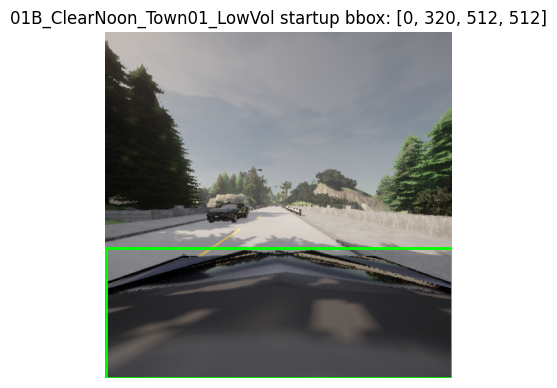

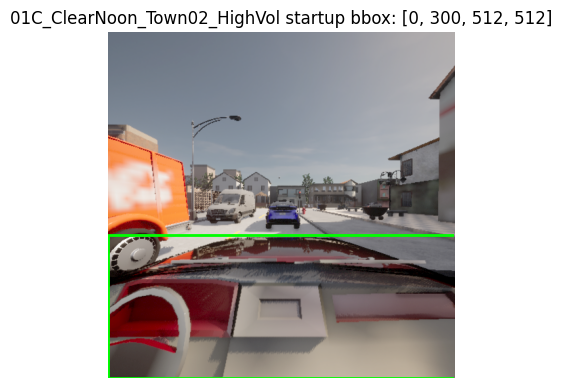

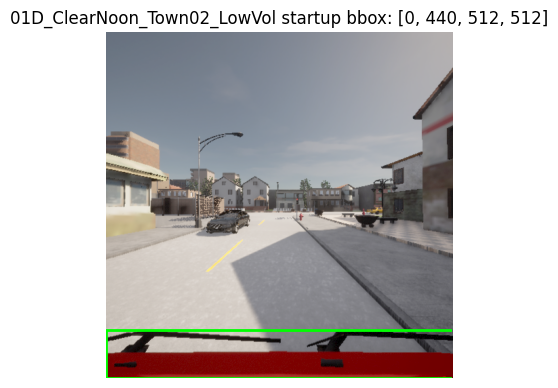

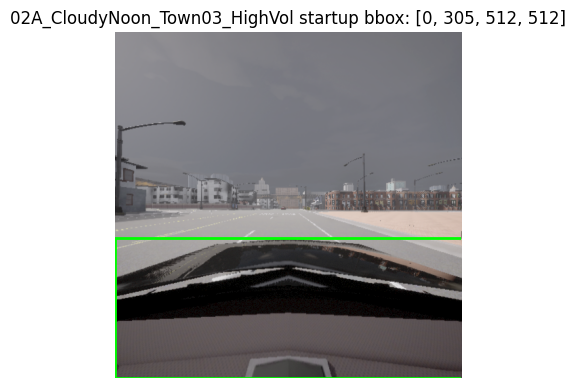

Displayed startup bounding boxes for 4 scenario(s).
Using device for feature extraction: cuda
Total records to process: 14400
Starting 01B_ClearNoon_Town01_LowVol: 3600 records
[01B_ClearNoon_Town01_LowVol] 25/3600 (0.7%) | written=25 errors=0 | scenario FPS=4.83 overall FPS=4.78 | ETA scenario=12.33m ETA global=50.09m | overall=25/14400 (0.2%)
[01B_ClearNoon_Town01_LowVol] 50/3600 (1.4%) | written=50 errors=0 | scenario FPS=5.44 overall FPS=5.41 | ETA scenario=10.88m ETA global=44.23m | overall=50/14400 (0.3%)
[01B_ClearNoon_Town01_LowVol] 75/3600 (2.1%) | written=75 errors=0 | scenario FPS=5.67 overall FPS=5.65 | ETA scenario=10.36m ETA global=42.27m | overall=75/14400 (0.5%)
[01B_ClearNoon_Town01_LowVol] 100/3600 (2.8%) | written=100 errors=0 | scenario FPS=5.78 overall FPS=5.77 | ETA scenario=10.09m ETA global=41.33m | overall=100/14400 (0.7%)
[01B_ClearNoon_Town01_LowVol] 125/3600 (3.5%) | written=125 errors=0 | scenario FPS=5.76 overall FPS=5.75 | ETA scenario=10.05m ETA global=4

KeyboardInterrupt: 

In [2]:
from pathlib import Path
import json
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from PIL import Image
from ultralytics import YOLO

from MIREIA.config import Config
from MIREIA.data_collection import label_scenario_dataset_with_bbox
from MIREIA.data_collection.dataset_utils import load_jsonl_records, resolve_image_path
from MIREIA.perception import (
    DepthAnythingV2Estimator,
    FeatureIntegrator,
    create_environment_classifier_predictor,
    load_road_segmentation_model,
)

if "SCENARIO_BBOX_MAP" not in globals() or not SCENARIO_BBOX_MAP:
    raise RuntimeError("Run Cell 20 first to define and preview the 4 dashboard bboxes.")

# ----------------------
# 1) Apply manual bbox per selected scenario (mask definition source)
# ----------------------
run_bbox_labeling = True
source_jsonl_name = "dataset.jsonl"
output_jsonl_name = "dataset_labeled.jsonl"
bbox_key = "crop_bbox_xyxy"
bbox_kind = "dashboard"

# ----------------------
# 2) Optional startup bbox preview
# ----------------------
show_startup_bboxes = True

# ----------------------
# 3) Full feature-vector labeling (all models) using masked frames
# ----------------------
run_feature_vector_labeling = True
feature_vector_key = "feature_vector_32"
feature_vector_source_key = "feature_vector_source"
max_feature_records_per_scenario = None  # set int for quicker test runs

# Progress tracker controls
show_progress = True
progress_every = 25  # print progress every N records

MODEL_PATHS = {
    "yolo": Path(Config.PATH_TO_MODELS) / "yolo11s.pt",
    "depth": Path(Config.PATH_TO_MODELS) / "depth_anything_v2_vits.pth",
    "climate": Path(Config.PATH_TO_MODELS) / "environment_multitask_checkpoint.pt",
    "road_seg": Path(Config.PATH_TO_MODELS) / "road_segmentation_multitask_checkpoint.pt",
}

def _clip_bbox_to_image(bbox_xyxy, width, height):
    x1, y1, x2, y2 = [int(v) for v in bbox_xyxy]
    x1 = max(0, min(width, x1))
    y1 = max(0, min(height, y1))
    x2 = max(0, min(width, x2))
    y2 = max(0, min(height, y2))
    if x2 <= x1 or y2 <= y1:
        return (0, 0, width, height)
    return (x1, y1, x2, y2)

def _mask_dashboard_region(frame_rgb: np.ndarray, bbox_xyxy):
    masked = frame_rgb.copy()
    h, w = masked.shape[:2]
    x1, y1, x2, y2 = _clip_bbox_to_image(bbox_xyxy, width=w, height=h)
    masked[y1:y2, x1:x2, :] = 0
    return masked

def _to_minutes(seconds: float) -> float:
    return float(seconds) / 60.0

summaries = []
selected_scenarios = list(PREVIEW_SELECTED_SCENARIOS) if "PREVIEW_SELECTED_SCENARIOS" in globals() else list(SCENARIO_BBOX_MAP.keys())

if run_bbox_labeling:
    for scenario_name in selected_scenarios:
        scenario_dir = Path(Config.PATH_TO_SCENARIOS) / scenario_name
        if not scenario_dir.is_dir():
            print(f"[warn] Scenario dir not found: {scenario_dir}")
            continue

        if scenario_name not in SCENARIO_BBOX_MAP:
            print(f"[warn] No bbox defined for {scenario_name}, skipping.")
            continue

        try:
            summary = label_scenario_dataset_with_bbox(
                scenario_dir=str(scenario_dir),
                mode="manual",
                manual_bbox_xyxy=SCENARIO_BBOX_MAP[scenario_name],
                source_jsonl_name=source_jsonl_name,
                output_jsonl_name=output_jsonl_name,
                bbox_key=bbox_key,
                bbox_kind=bbox_kind,
            )
            summaries.append(summary)
        except Exception as exc:
            print(f"[warn] Failed bbox labeling for {scenario_name}: {exc}")

    print(f"Labeled scenarios (manual bboxes): {len(summaries)}")
else:
    print("BBox labeling skipped.")

target_jsonls = [Path(summary.output_jsonl_path) for summary in summaries]
if not target_jsonls:
    print("No new labeled outputs from this run; trying existing labeled jsonl files for selected scenarios.")
    for scenario_name in selected_scenarios:
        candidate = Path(Config.PATH_TO_SCENARIOS) / scenario_name / output_jsonl_name
        if candidate.is_file():
            target_jsonls.append(candidate)

if show_startup_bboxes:
    shown = 0
    for labeled_jsonl_path in target_jsonls:
        records = load_jsonl_records(str(labeled_jsonl_path))
        if not records:
            continue

        scenario_name = labeled_jsonl_path.parent.name
        bbox = SCENARIO_BBOX_MAP.get(scenario_name, records[0].get(bbox_key))
        rel_image = str(records[0].get("rgb_image_path", "")).strip()
        if not bbox or not rel_image:
            continue

        image_path = Path(
            resolve_image_path(
                image_root=str(labeled_jsonl_path.parent),
                rel_path=rel_image,
                normalize_paths=True,
            )
        )
        if not image_path.is_file():
            continue

        with Image.open(image_path) as img:
            rgb = img.convert("RGB")
            x1, y1, x2, y2 = _clip_bbox_to_image(bbox, rgb.width, rgb.height)
            fig, ax = plt.subplots(figsize=(8, 4.5))
            ax.imshow(rgb)
            rect = patches.Rectangle(
                (x1, y1),
                max(1, x2 - x1),
                max(1, y2 - y1),
                linewidth=2,
                edgecolor="lime",
                facecolor="none",
            )
            ax.add_patch(rect)
            ax.set_title(f"{scenario_name} startup bbox: [{x1}, {y1}, {x2}, {y2}]")
            ax.axis("off")
            plt.show()
            shown += 1

    if shown == 0:
        print("No startup bounding boxes found to preview.")
    else:
        print(f"Displayed startup bounding boxes for {shown} scenario(s).")

if run_feature_vector_labeling:
    missing_required = [k for k in ("yolo", "depth") if not MODEL_PATHS[k].is_file()]
    if missing_required:
        print("Feature labeling skipped. Missing required model checkpoint(s):")
        for name in missing_required:
            print(f" - {name}: {MODEL_PATHS[name]}")
    elif not target_jsonls:
        print("Feature labeling skipped. No dataset_labeled.jsonl files found.")
    else:
        device_name = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Using device for feature extraction: {device_name}")

        yolo_model = YOLO(str(MODEL_PATHS["yolo"]))
        depth_estimator = DepthAnythingV2Estimator(
            checkpoint_path=MODEL_PATHS["depth"],
            encoder="vits",
            device=device_name,
        )

        environment_predictor = None
        if MODEL_PATHS["climate"].is_file():
            environment_predictor = create_environment_classifier_predictor(
                checkpoint_path=str(MODEL_PATHS["climate"]),
                device=device_name,
            )
        else:
            print(f"[info] Climate checkpoint missing, defaults will be used: {MODEL_PATHS['climate']}")

        road_segmentation = None
        if MODEL_PATHS["road_seg"].is_file():
            road_segmentation = load_road_segmentation_model(
                checkpoint_path=str(MODEL_PATHS["road_seg"]),
                device=device_name,
            )
        else:
            print(f"[info] Road segmentation checkpoint missing, default road value will be used: {MODEL_PATHS['road_seg']}")

        integrator = FeatureIntegrator()
        total_written = 0
        total_errors = 0

        # Precompute total work to enable overall ETA and FPS reporting.
        scenario_limits: dict[str, int] = {}
        total_records_to_process = 0
        for labeled_jsonl_path in target_jsonls:
            recs = load_jsonl_records(str(labeled_jsonl_path))
            if not recs:
                scenario_limits[str(labeled_jsonl_path)] = 0
                continue
            lim = len(recs) if max_feature_records_per_scenario is None else min(len(recs), int(max_feature_records_per_scenario))
            scenario_limits[str(labeled_jsonl_path)] = lim
            total_records_to_process += lim

        global_processed = 0
        pipeline_start = time.time()

        print(f"Total records to process: {total_records_to_process}")

        for labeled_jsonl_path in target_jsonls:
            records = load_jsonl_records(str(labeled_jsonl_path))
            if not records:
                continue

            scenario_name = labeled_jsonl_path.parent.name
            scenario_bbox = SCENARIO_BBOX_MAP.get(scenario_name)
            if scenario_bbox is None:
                scenario_bbox = records[0].get(bbox_key)
            if scenario_bbox is None:
                print(f"[warn] No bbox available for {scenario_name}; skipping scenario.")
                continue

            written_here = 0
            errors_here = 0
            limit = scenario_limits.get(str(labeled_jsonl_path), 0)
            if limit <= 0:
                print(f"{scenario_name}: no records to process.")
                continue

            scenario_start = time.time()
            print(f"Starting {scenario_name}: {limit} records")

            for idx in range(limit):
                rec_curr = records[idx]
                rec_prev = records[idx - 1] if idx > 0 else records[idx]

                rel_prev = str(rec_prev.get("rgb_image_path", "")).strip()
                rel_curr = str(rec_curr.get("rgb_image_path", "")).strip()
                if not rel_prev or not rel_curr:
                    rec_curr[feature_vector_key] = [0.0] * 32
                    rec_curr[feature_vector_source_key] = "missing_rgb_image_path"
                    errors_here += 1
                    global_processed += 1
                    continue

                path_prev = Path(resolve_image_path(str(labeled_jsonl_path.parent), rel_prev, True))
                path_curr = Path(resolve_image_path(str(labeled_jsonl_path.parent), rel_curr, True))
                if not path_prev.is_file() or not path_curr.is_file():
                    rec_curr[feature_vector_key] = [0.0] * 32
                    rec_curr[feature_vector_source_key] = "missing_image_file"
                    errors_here += 1
                    global_processed += 1
                    continue

                try:
                    with Image.open(path_prev) as img_prev:
                        frame_prev = np.asarray(img_prev.convert("RGB"), dtype=np.uint8)
                    with Image.open(path_curr) as img_curr:
                        frame_curr = np.asarray(img_curr.convert("RGB"), dtype=np.uint8)

                    frame_prev_masked = _mask_dashboard_region(frame_prev, scenario_bbox)
                    frame_curr_masked = _mask_dashboard_region(frame_curr, scenario_bbox)

                    vec = integrator.extract_state_vector_from_sources(
                        source_frame1=frame_prev_masked,
                        source_frame2=frame_curr_masked,
                        yolo_model=yolo_model,
                        depth_estimator=depth_estimator,
                        environment_predictor=environment_predictor,
                        road_segmentation=road_segmentation,
                    )

                    rec_curr[feature_vector_key] = [float(v) for v in vec.view(-1).tolist()]
                    rec_curr[feature_vector_source_key] = "all_models_masked"
                    written_here += 1
                except Exception:
                    rec_curr[feature_vector_key] = [0.0] * 32
                    rec_curr[feature_vector_source_key] = "feature_extraction_error"
                    errors_here += 1

                global_processed += 1

                if show_progress and (((idx + 1) % max(1, progress_every) == 0) or (idx + 1 == limit)):
                    elapsed_s = time.time() - scenario_start
                    fps_s = (idx + 1) / max(elapsed_s, 1e-6)
                    rem_s = limit - (idx + 1)
                    eta_s = rem_s / max(fps_s, 1e-6)

                    elapsed_g = time.time() - pipeline_start
                    fps_g = global_processed / max(elapsed_g, 1e-6)
                    rem_g = max(0, total_records_to_process - global_processed)
                    eta_g = rem_g / max(fps_g, 1e-6)

                    pct_s = 100.0 * (idx + 1) / max(limit, 1)
                    pct_g = 100.0 * global_processed / max(total_records_to_process, 1)

                    print(
                        f"[{scenario_name}] {idx + 1}/{limit} ({pct_s:.1f}%) | "
                        f"written={written_here} errors={errors_here} | "
                        f"scenario FPS={fps_s:.2f} overall FPS={fps_g:.2f} | "
                        f"ETA scenario={_to_minutes(eta_s):.2f}m ETA global={_to_minutes(eta_g):.2f}m | "
                        f"overall={global_processed}/{total_records_to_process} ({pct_g:.1f}%)"
                    )

            with open(labeled_jsonl_path, "w", encoding="utf-8") as handle:
                for rec in records:
                    handle.write(json.dumps(rec) + "\n")

            # File-level verification summary: what you should see in dataset_labeled.jsonl
            vectors_in_file = 0
            vectors_len32 = 0
            for rec in records:
                vec_val = rec.get(feature_vector_key)
                if isinstance(vec_val, list):
                    vectors_in_file += 1
                    if len(vec_val) == 32:
                        vectors_len32 += 1

            first = records[0] if records else {}
            first_vec = first.get(feature_vector_key)
            first_vec_len = len(first_vec) if isinstance(first_vec, list) else 0

            total_written += written_here
            total_errors += errors_here
            print(
                f"{scenario_name}: wrote masked vectors for {written_here} records, "
                f"errors/defaulted={errors_here}"
            )
            print(
                f"{scenario_name}: file check -> has '{bbox_key}'={bbox_key in first}, "
                f"has '{feature_vector_key}'={feature_vector_key in first}, "
                f"first_vector_len={first_vec_len}, "
                f"vectors_len32={vectors_len32}/{len(records)}"
            )
            print(f"Saved file: {labeled_jsonl_path}")

        total_elapsed = time.time() - pipeline_start
        avg_fps = total_records_to_process / max(total_elapsed, 1e-6)
        print(
            f"Feature-vector labeling complete. total_written={total_written}, "
            f"total_errors={total_errors}, elapsed={total_elapsed:.1f}s ({_to_minutes(total_elapsed):.2f}m), "
            f"avg FPS={avg_fps:.2f}"
        )
else:
    print("Feature-vector labeling skipped (set run_feature_vector_labeling=True).")